In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torchvision.utils import make_grid
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [34]:
class EncodedImageDataset(Dataset):
    def __init__(self, images, weights, traj_joint, traj_task):
        min_length = min(len(images), len(weights), len(traj_joint), len(traj_task))
        self.images = images[:min_length]
        self.weights = weights[:min_length]
        self.traj_joint = traj_joint[:min_length]
        self.traj_task = traj_task[:min_length]
        print(f"Dataset initialized with {min_length} samples")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.weights[idx], self.traj_joint[idx], self.traj_task[idx]

def custom_collate_fn(batch):
    images, weights, traj_joint, traj_task = zip(*batch)
    images = torch.stack(images)
    weights = torch.stack(weights)

    max_joint_len = max(tj.size(0) for tj in traj_joint)
    max_joint_dim = max(tj.size(-1) for tj in traj_joint)
    padded_traj_joint = torch.zeros(len(traj_joint), max_joint_len, max_joint_dim)

    max_task_len = max(tt.size(0) for tt in traj_task)
    max_task_dim = max(tt.size(-1) for tt in traj_task)  # Changed 'tj' to 'tt' here
    padded_traj_task = torch.zeros(len(traj_task), max_task_len, max_task_dim)

    for i, (tj, tt) in enumerate(zip(traj_joint, traj_task)):
        if tj.dim() == 2:
            padded_traj_joint[i, :tj.size(0), :tj.size(1)] = tj
        elif tj.dim() == 3:
            padded_traj_joint[i, :tj.size(0), :tj.size(2)] = tj.squeeze(1)
        if tt.dim() == 2:
            padded_traj_task[i, :tt.size(0), :tt.size(1)] = tt
        elif tt.dim() == 3:
            padded_traj_task[i, :tt.size(0), :tt.size(2)] = tt.squeeze(1)

    return images, weights, padded_traj_joint, padded_traj_task

In [35]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [36]:
class ViT(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_ratio=4.):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=0.1)

        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=int(embed_dim * mlp_ratio))
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x[:, 0]
        x = self.head(x)
        return x

In [37]:
def euclidean_loss(predictions, targets):
    return torch.sqrt(torch.sum((predictions - targets) ** 2, dim=1)).mean()

In [38]:
def load_data(folder):
    files = [os.path.join(folder, file) for file in os.listdir(folder) if file.endswith('.npy')]
    data = [torch.tensor(np.load(file), dtype=torch.float32) for file in files]
    return data

def train_model(model, train_loader, num_epochs, learning_rate):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses = []
    metrics = {'MSE': [], 'MAE': [], 'R2': [], 'Accuracy': []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for i, (images, weights, _, _) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = euclidean_loss(outputs, weights)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if (i+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

        # Evaluate the model after each epoch
        mse, mae, r2, accuracy = evaluate_model(model, train_loader)
        metrics['MSE'].append(mse)
        metrics['MAE'].append(mae)
        metrics['R2'].append(r2)
        metrics['Accuracy'].append(accuracy)

    return losses, metrics

def evaluate_model(model, dataloader):
    model.eval()
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for images, weights, _, _ in dataloader:
            outputs = model(images)
            all_predictions.append(outputs)
            all_targets.append(weights)

    all_predictions = torch.cat(all_predictions, dim=0).cpu().numpy()
    all_targets = torch.cat(all_targets, dim=0).cpu().numpy()

    mse = mean_squared_error(all_targets, all_predictions)
    mae = mean_absolute_error(all_targets, all_predictions)
    r2 = r2_score(all_targets, all_predictions)
    accuracy = np.mean(np.abs((all_predictions - all_targets) / all_targets) < 0.1)

    print(f"Evaluation Metrics:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Accuracy (within 10%): {accuracy:.4f}")

    return mse, mae, r2, accuracy

In [39]:
def visualize_encoded_images(encoded_images, num_images=16):
    sample_images = encoded_images[:num_images]
    grid = make_grid(sample_images, nrow=4, normalize=True, pad_value=1)
    grid_np = grid.numpy().transpose((1, 2, 0))

    fig, ax = plt.subplots(figsize=(15, 15))
    im = ax.imshow(grid_np)
    ax.set_title(f"Sample of {num_images} Encoded Images")
    ax.axis('off')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax)
    plt.show()

def visualize_weight_distribution(weights):
    all_weights = torch.cat(weights, dim=0).numpy()
    plt.figure(figsize=(12, 6))
    counts, bins, patches = plt.hist(all_weights.flatten(), bins=50, edgecolor='black')
    fracs = counts / counts.max()
    norm = Normalize(fracs.min(), fracs.max())
    for frac, patch in zip(fracs, patches):
        color = plt.cm.viridis(norm(frac))
        patch.set_facecolor(color)
    sm = ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Normalized Frequency')
    plt.title("Distribution of Weights")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.show()

def visualize_trajectory(traj_data, traj_type="Joint", num_samples=5):
    plt.figure(figsize=(15, 5 * num_samples))
    color_map = plt.cm.get_cmap('tab20')
    for i in range(num_samples):
        traj = traj_data[i].numpy()
        ax = plt.subplot(num_samples, 1, i+1)
        for j in range(traj.shape[1]):
            color = color_map(j / traj.shape[1])
            ax.plot(traj[:, j], color=color, label=f"Dimension {j+1}")
        ax.set_title(f"{traj_type} Trajectory Sample {i+1}")
        ax.set_xlabel("Time Step")
        ax.set_ylabel("Value")
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def visualize_prediction_vs_target(model, dataloader):
    model.eval()
    with torch.no_grad():
        images, weights, _, _ = next(iter(dataloader))
        outputs = model(images)
    plt.figure(figsize=(20, 15))
    for i in range(min(8, outputs.shape[1])):
        ax = plt.subplot(2, 4, i+1)
        scatter = ax.scatter(weights[:, i].cpu(), outputs[:, i].cpu(),
                             c=range(len(weights)), cmap='viridis', alpha=0.7)
        ax.plot([weights[:, i].min(), weights[:, i].max()],
                [weights[:, i].min(), weights[:, i].max()], 'r--')
        ax.set_title(f'Weight {i+1}')
        ax.set_xlabel('True Value')
        ax.set_ylabel('Predicted Value')
        plt.colorbar(scatter, label='Sample Index')
    plt.tight_layout()
    plt.show()

In [40]:
def plot_training_progress(losses, metrics):
    epochs = range(1, len(losses) + 1)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot loss
    ax1.plot(epochs, losses, 'bo-', label='Training Loss')
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot metrics on log scale
    color_map = plt.cm.get_cmap('Set1')
    for i, (metric_name, metric_values) in enumerate(metrics.items()):
        color = color_map(i / len(metrics))
        ax2.semilogy(epochs, metric_values, 'o-', color=color, label=metric_name)

    ax2.set_title('Evaluation Metrics (Log Scale)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Value (Log Scale)')
    ax2.legend()
    plt.tight_layout()
    plt.show()

In [41]:
def visualize_data(encoded_images, weights, traj_joint_data, traj_task_data):
    print("Visualizing encoded images...")
    visualize_encoded_images(encoded_images)
    print("Visualizing weight distribution...")
    visualize_weight_distribution(weights)
    print("Visualizing joint trajectories...")
    visualize_trajectory(traj_joint_data, traj_type="Joint")
    print("Visualizing task trajectories...")
    visualize_trajectory(traj_task_data, traj_type="Task")

def visualize_model_performance(model, train_loader, losses, metrics):
    print("Visualizing predictions vs targets...")
    visualize_prediction_vs_target(model, train_loader)
    print("Plotting training progress...")
    plot_training_progress(losses, metrics)

In [42]:
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# Main execution
if __name__ == "__main__":
    base_path = '/content/drive/MyDrive/Data'
    image_folder = os.path.join(base_path, 'img_encoded')
    weights_folder = os.path.join(base_path, 'weights')
    traj_joint_folder = os.path.join(base_path, 'traj_joint')
    traj_task_folder = os.path.join(base_path, 'traj_task')

    encoded_images = load_data(image_folder)
    weights = load_data(weights_folder)
    traj_joint_data = load_data(traj_joint_folder)
    traj_task_data = load_data(traj_task_folder)

    print(f"Number of images: {len(encoded_images)}")
    print(f"Number of weights: {len(weights)}")
    print(f"Number of joint trajectories: {len(traj_joint_data)}")
    print(f"Number of task trajectories: {len(traj_task_data)}")

    dataset = EncodedImageDataset(encoded_images, weights, traj_joint_data, traj_task_data)
    train_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=custom_collate_fn)

Number of images: 130
Number of weights: 100
Number of joint trajectories: 100
Number of task trajectories: 100
Dataset initialized with 100 samples


In [48]:
# Hyperparameters
image_size = 8
patch_size = 2
in_channels = 3
num_classes = 70
embed_dim = 256
depth = 6
num_heads = 8
num_epochs = 10
learning_rate = 0.001

model = ViT(image_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads)

Visualizing encoded images...


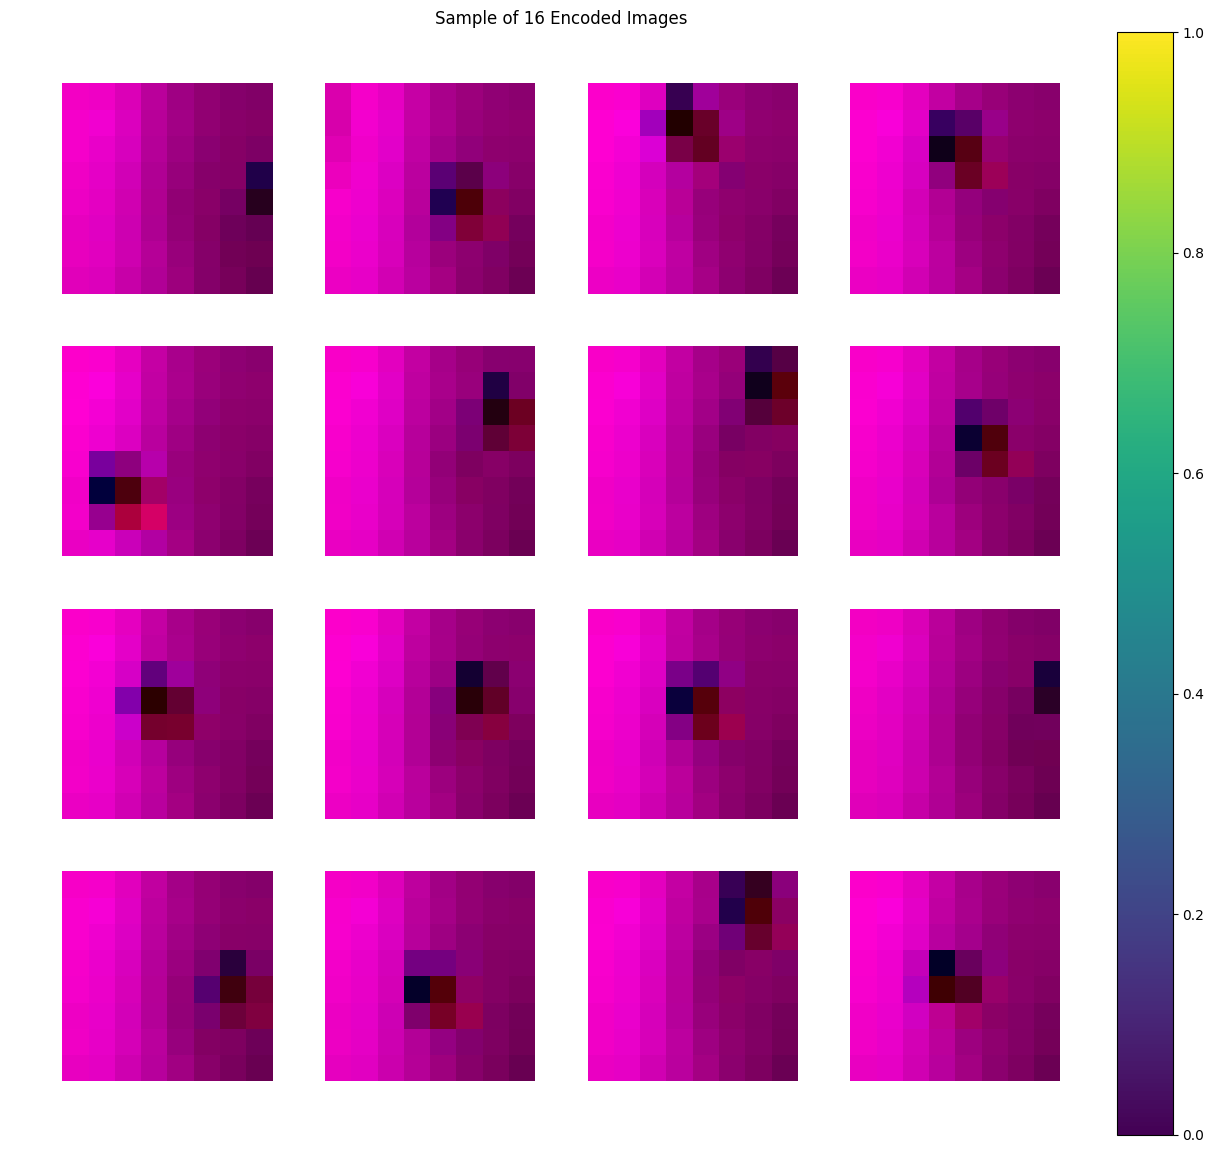

Visualizing weight distribution...


<ipython-input-39-ba1c30e671f2>:27: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Normalized Frequency')


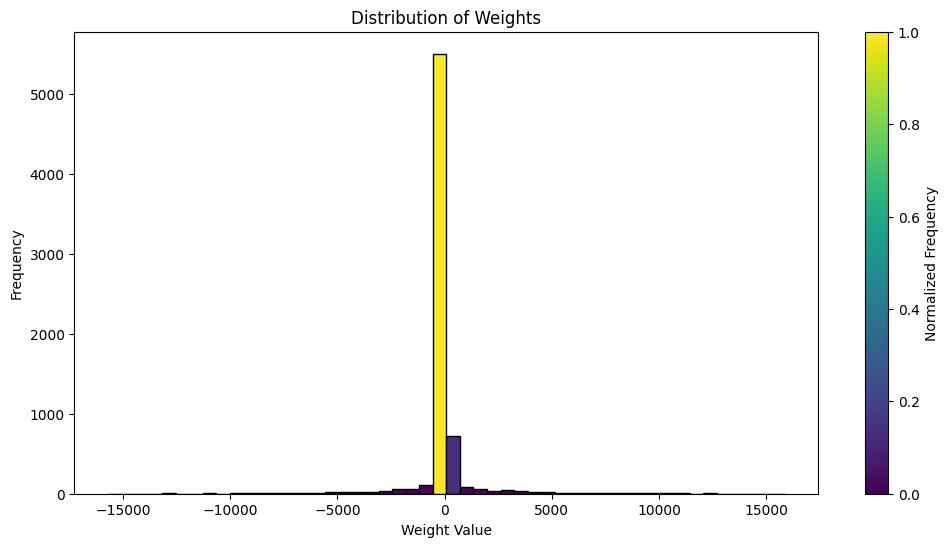

Visualizing joint trajectories...


<ipython-input-39-ba1c30e671f2>:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab20')


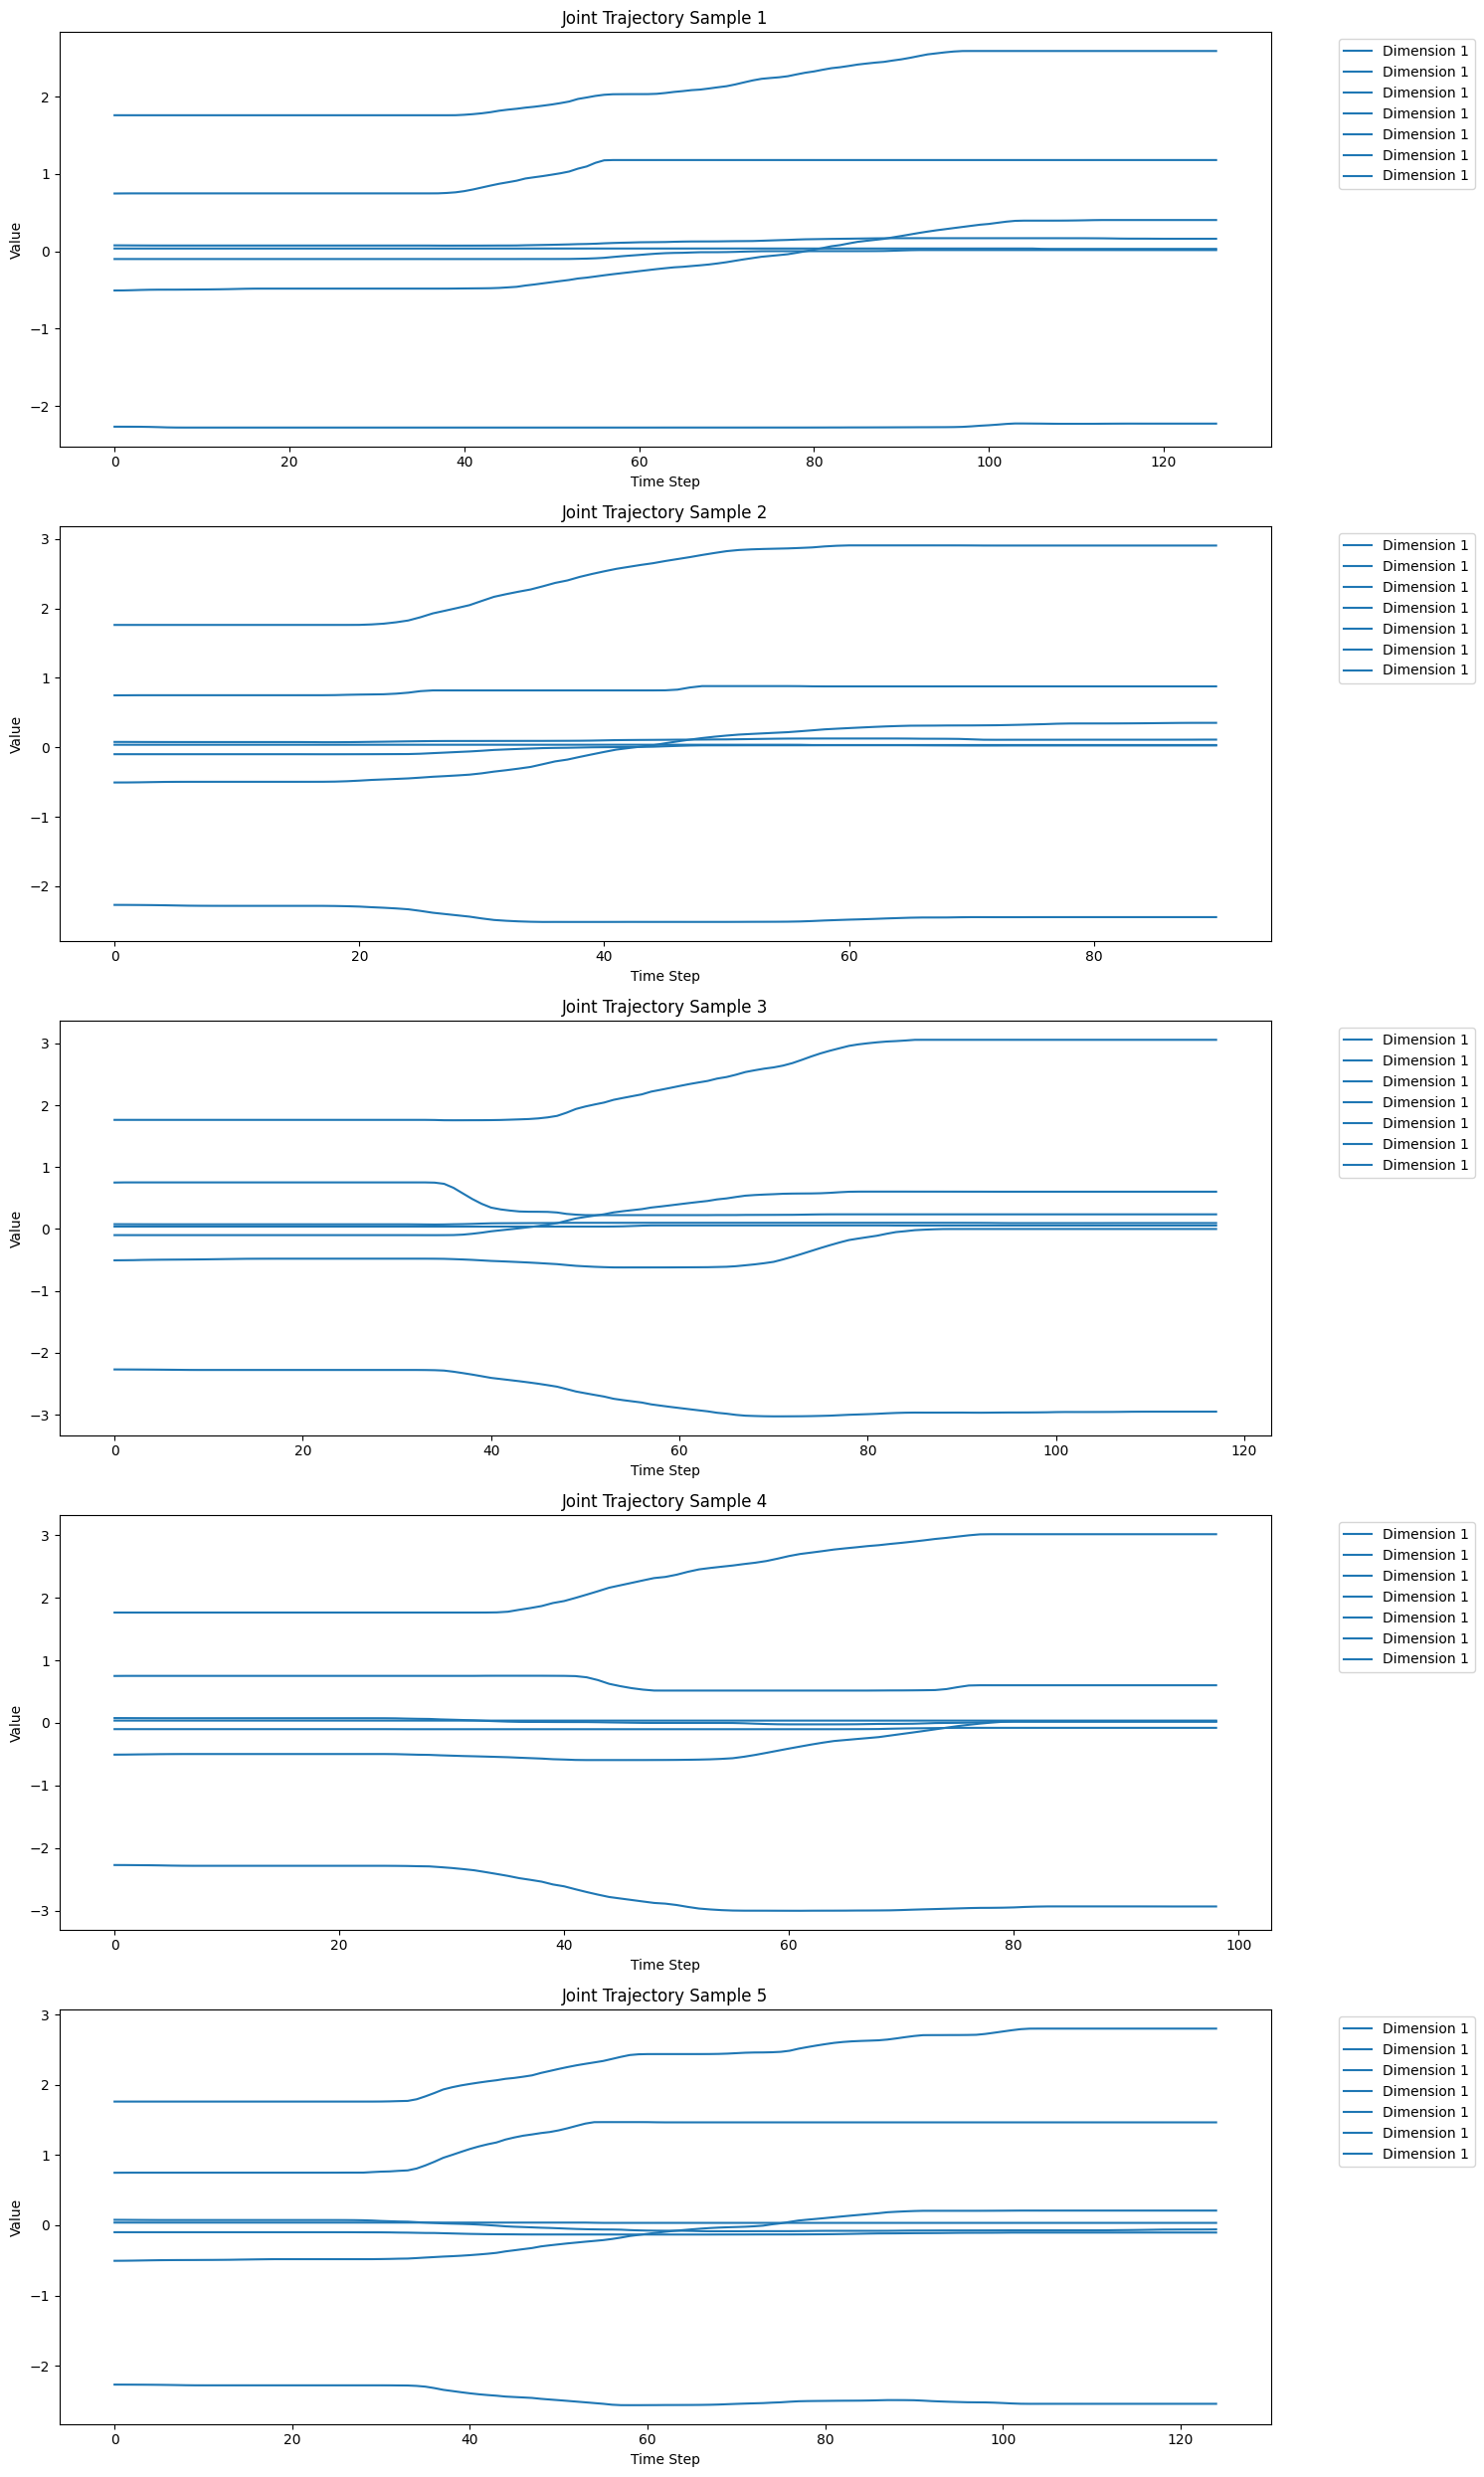

Visualizing task trajectories...


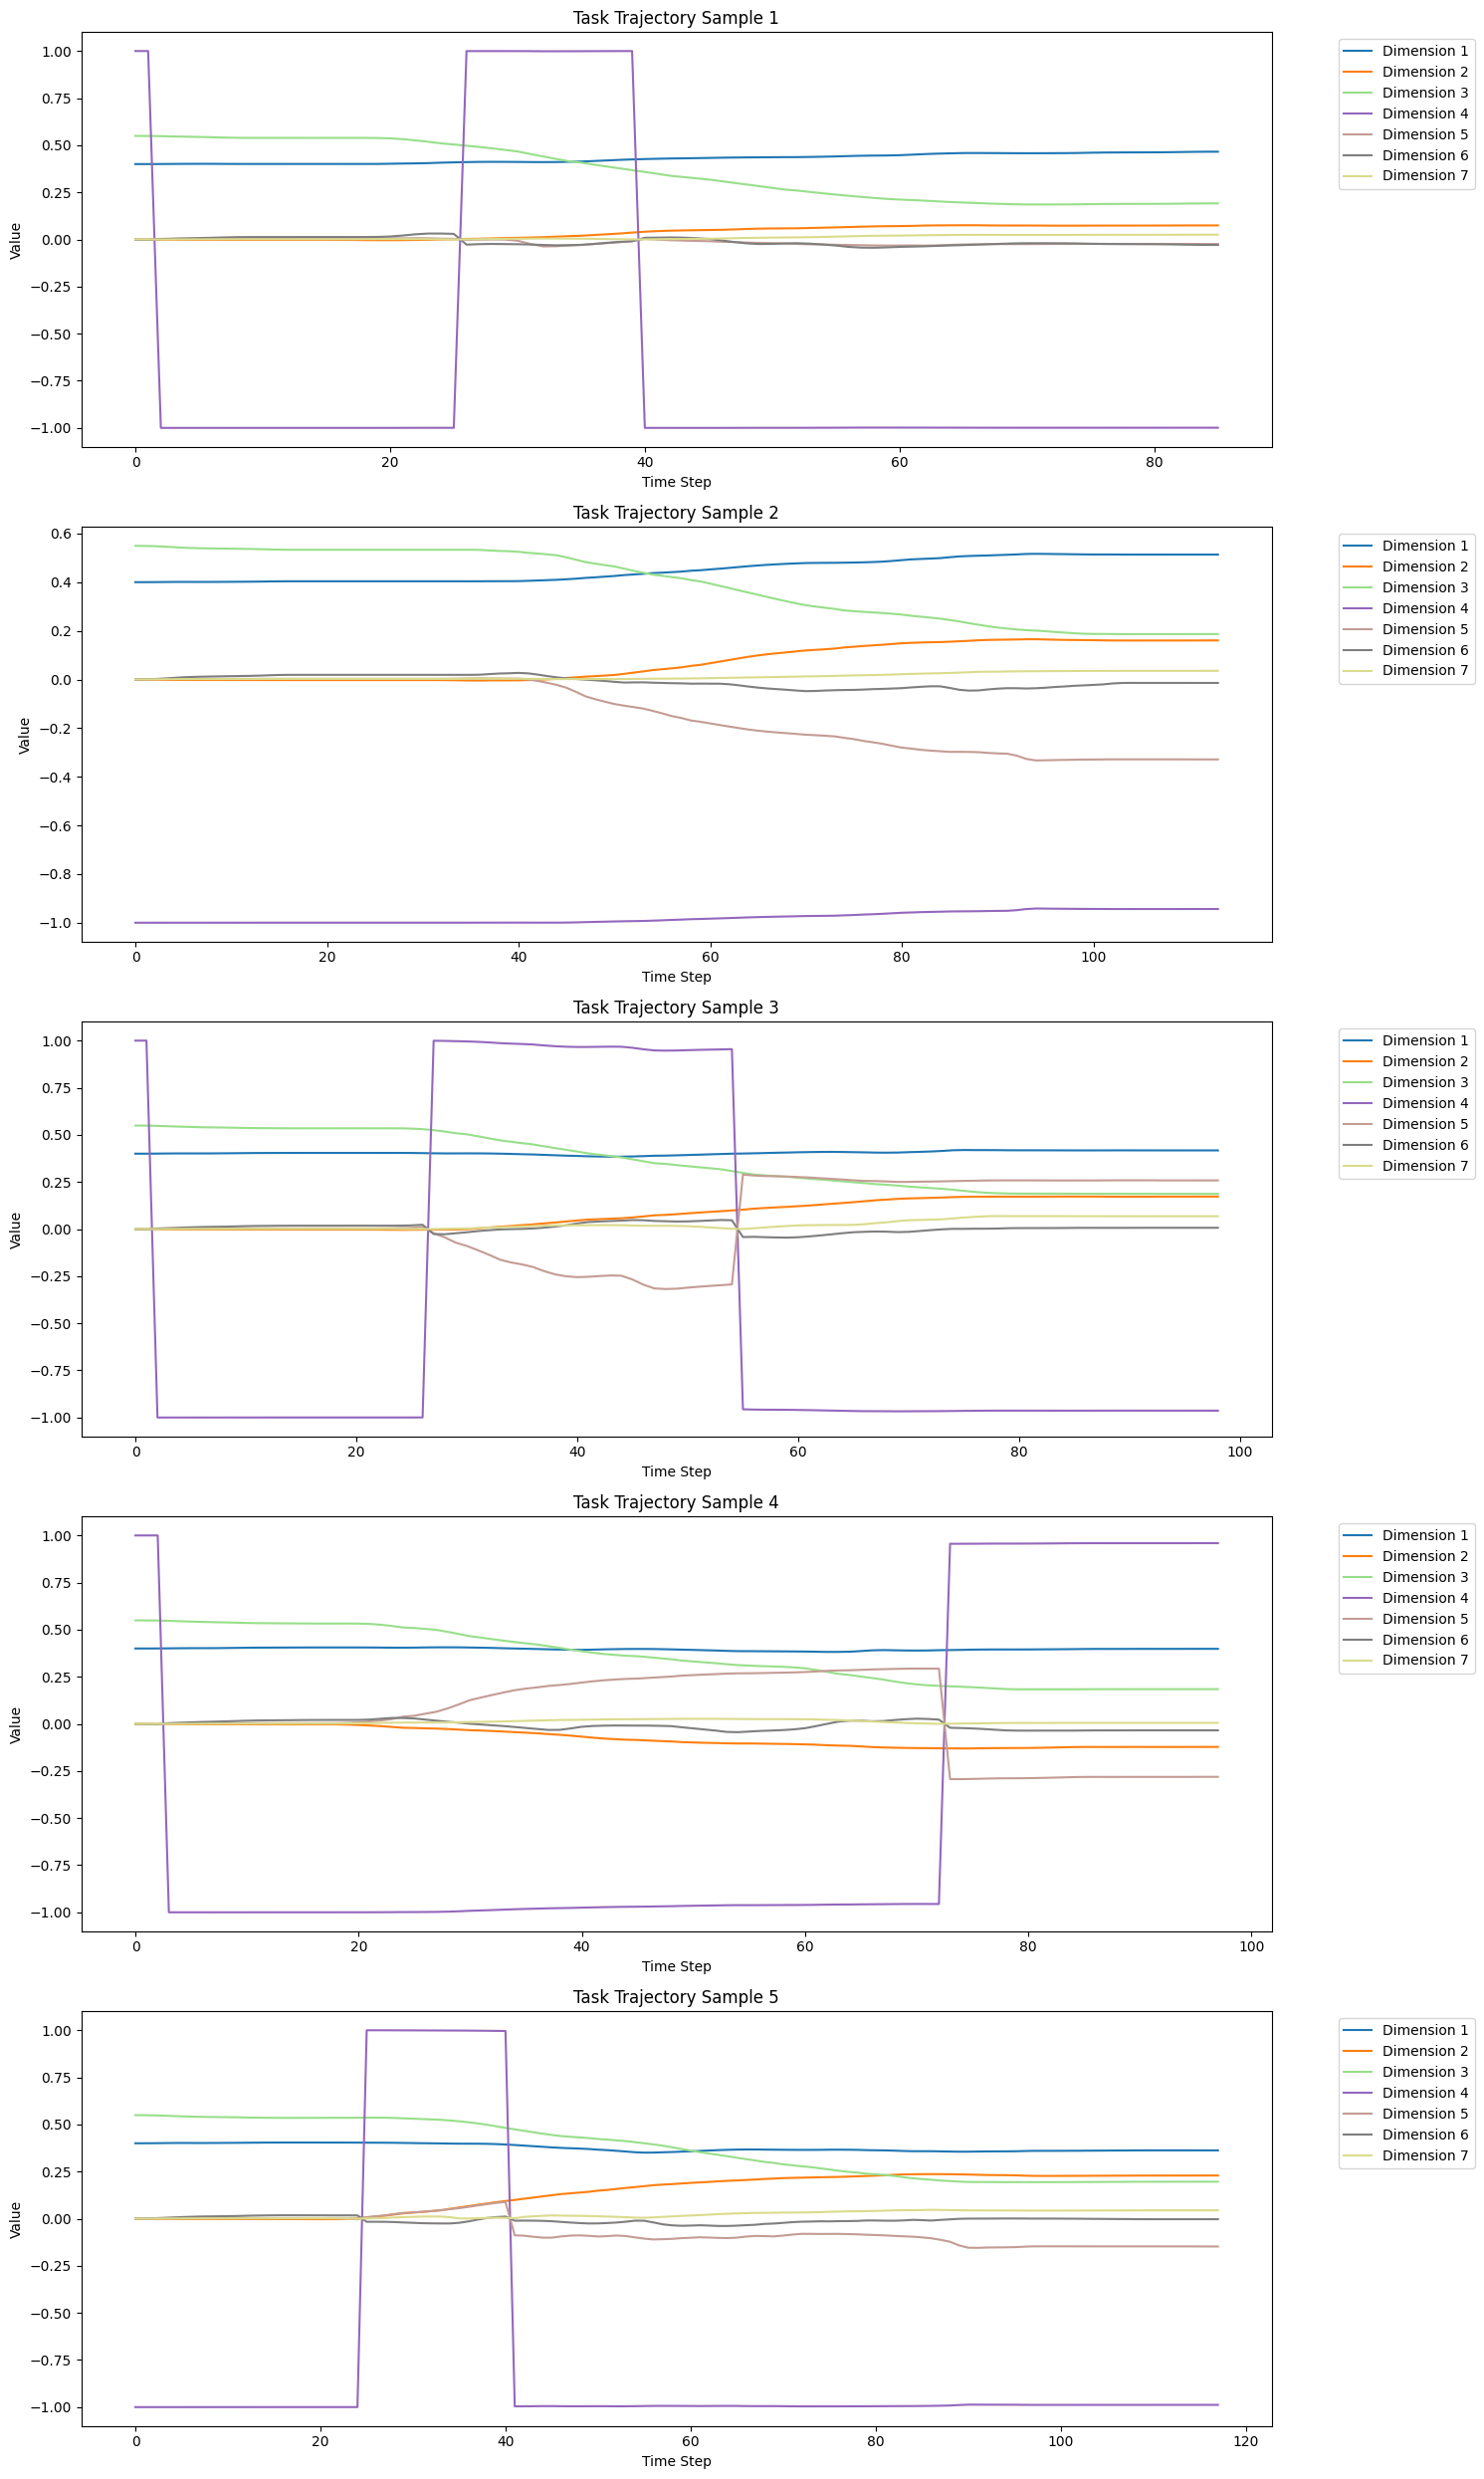

Epoch [1/10], Step [10/13], Loss: 9900.9844
Epoch [1/10], Average Loss: 9833.8695
Evaluation Metrics:
MSE: 2191408.2500
MAE: 433.0038
R2 Score: -0.0829
Accuracy (within 10%): 0.0027
Epoch [2/10], Step [10/13], Loss: 6373.7837
Epoch [2/10], Average Loss: 9648.5055
Evaluation Metrics:
MSE: 2190635.0000
MAE: 432.8280
R2 Score: -0.0751
Accuracy (within 10%): 0.0041
Epoch [3/10], Step [10/13], Loss: 10079.0283
Epoch [3/10], Average Loss: 9604.3963
Evaluation Metrics:
MSE: 2189875.2500
MAE: 432.6553
R2 Score: -0.0706
Accuracy (within 10%): 0.0069
Epoch [4/10], Step [10/13], Loss: 7010.5596
Epoch [4/10], Average Loss: 9371.6385
Evaluation Metrics:
MSE: 2189034.7500
MAE: 432.4931
R2 Score: -0.0669
Accuracy (within 10%): 0.0067
Epoch [5/10], Step [10/13], Loss: 7340.3091
Epoch [5/10], Average Loss: 9732.1572
Evaluation Metrics:
MSE: 2188040.5000
MAE: 432.3126
R2 Score: -0.0611
Accuracy (within 10%): 0.0064
Epoch [6/10], Step [10/13], Loss: 9059.3223
Epoch [6/10], Average Loss: 9676.7827
Evaluat

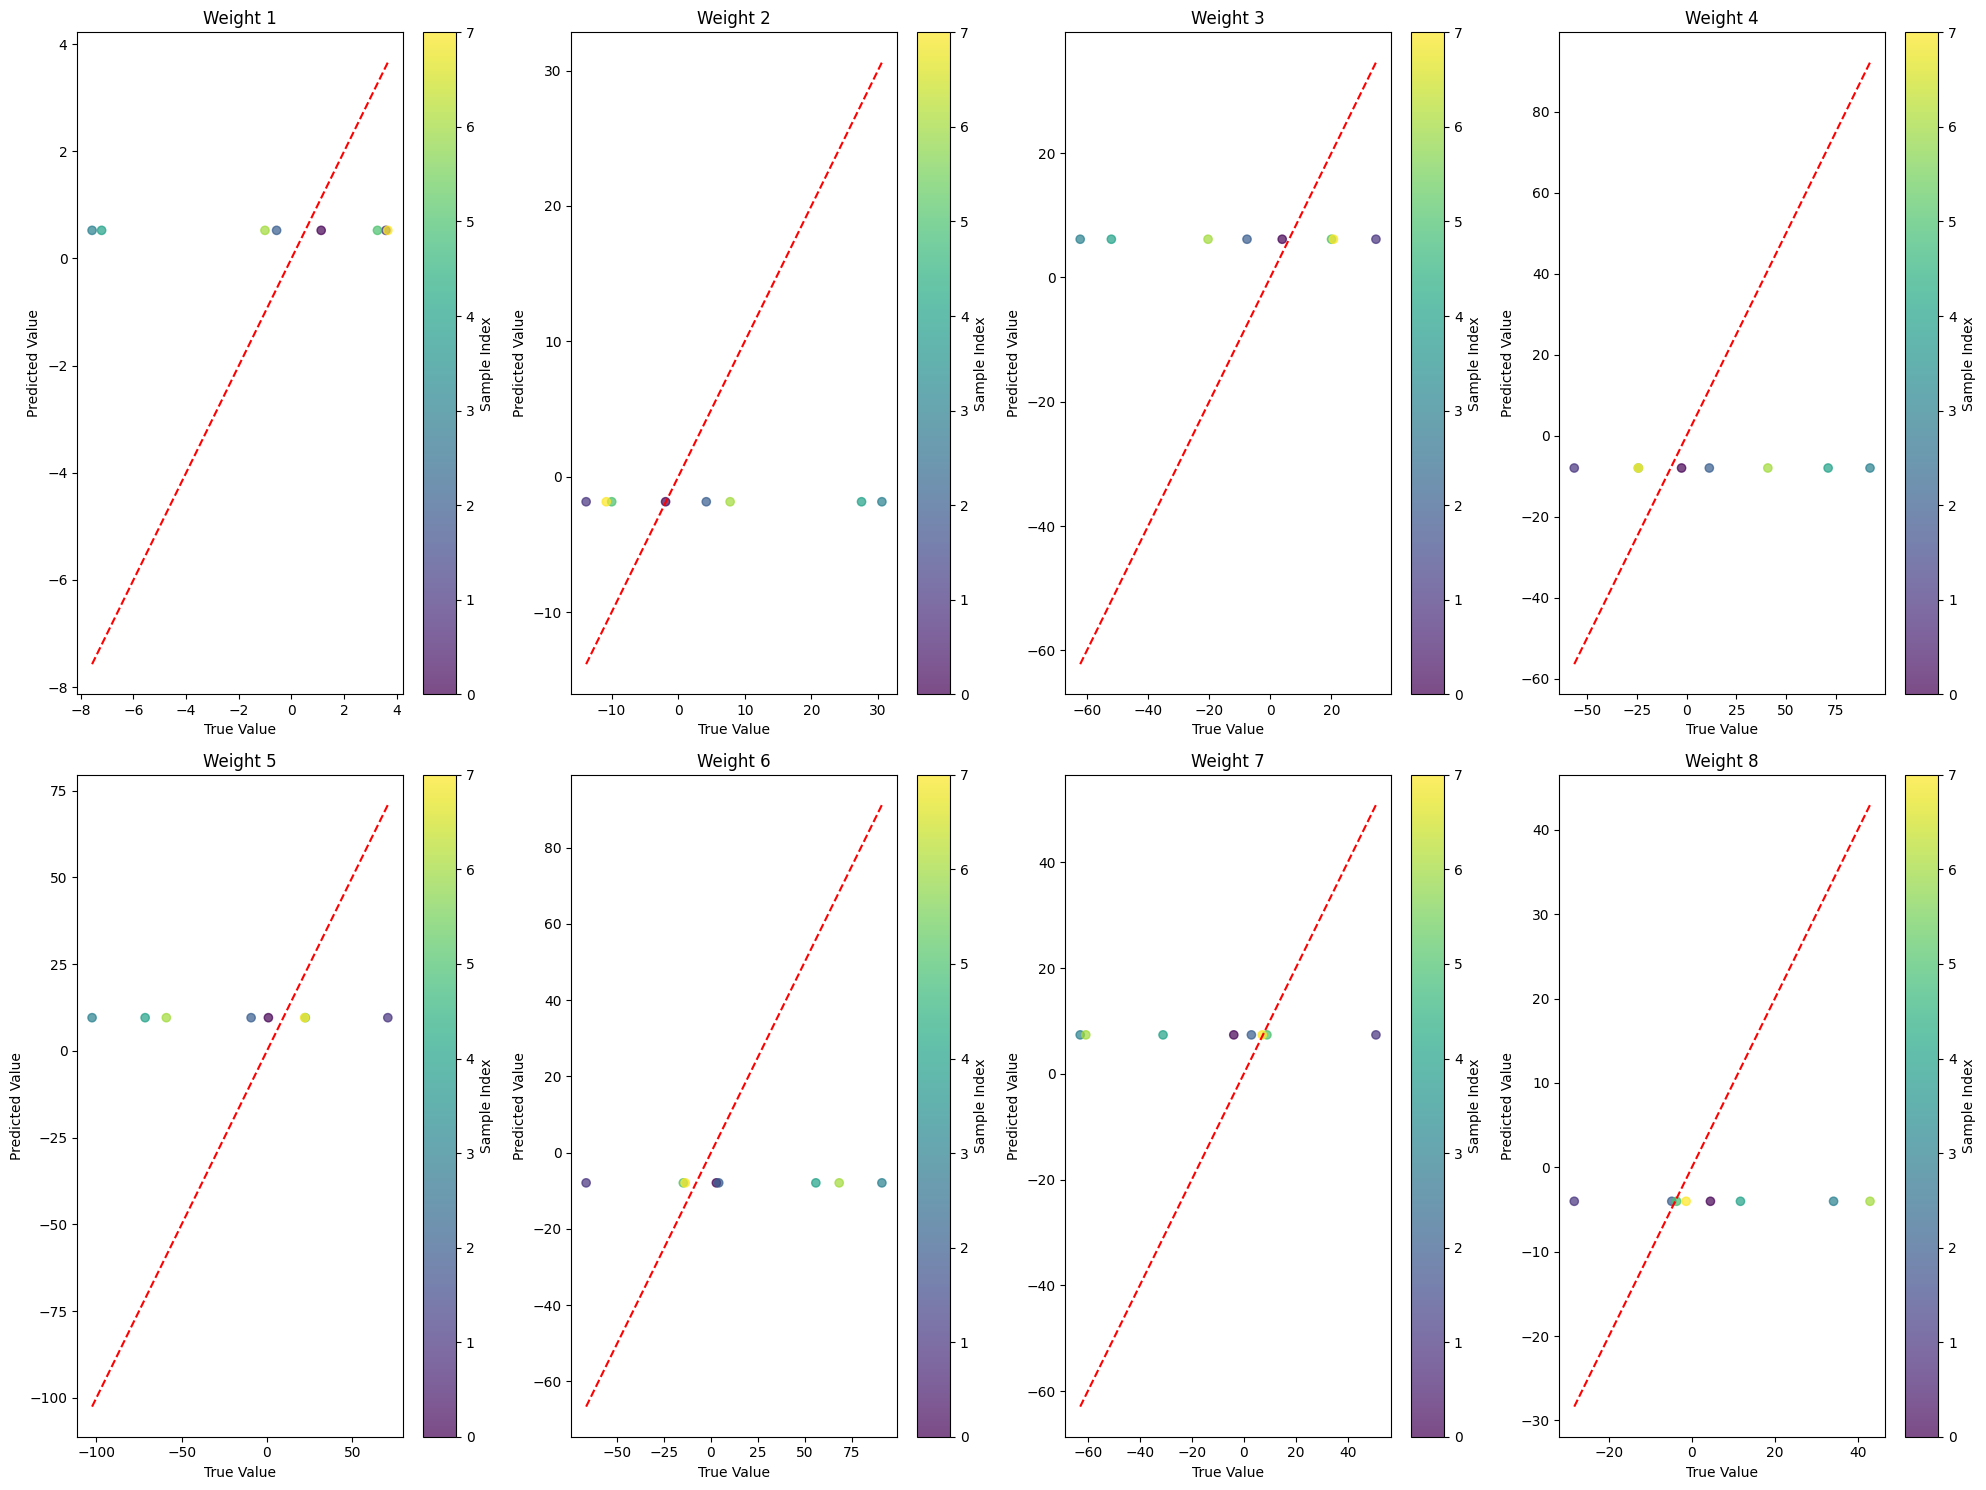

Plotting training progress...


<ipython-input-40-383f352ecf7e>:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('Set1')


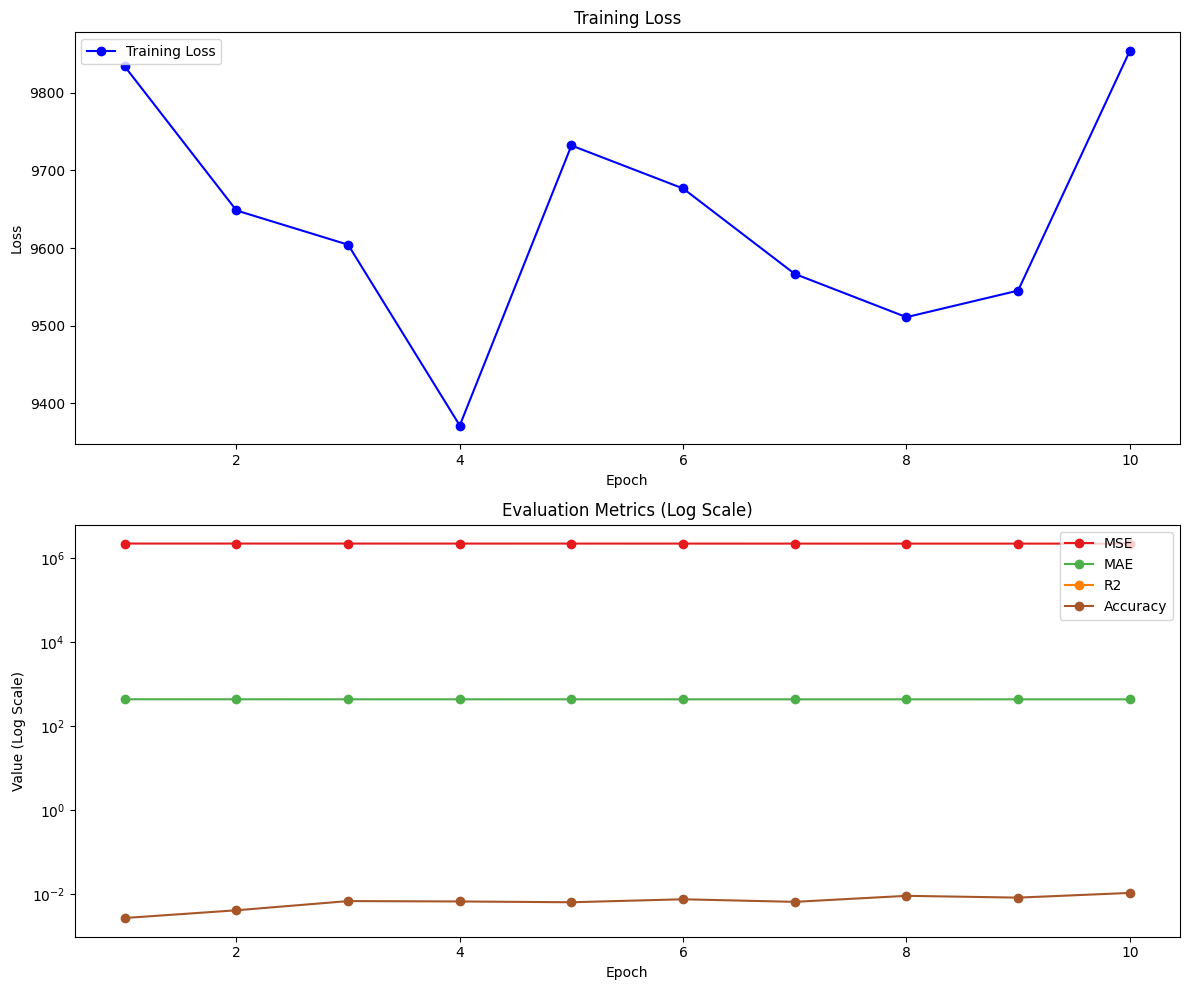

Final Evaluation:
Evaluation Metrics:
MSE: 2182474.2500
MAE: 431.6357
R2 Score: -0.0481
Accuracy (within 10%): 0.0107
Model saved successfully.
Script execution completed.


In [49]:
 # Visualize input data
visualize_data(encoded_images, weights, traj_joint_data, traj_task_data)

# Train the model
losses, metrics = train_model(model, train_loader, num_epochs, learning_rate)

# Visualize model performance
visualize_model_performance(model, train_loader, losses, metrics)

# Final evaluation
print("Final Evaluation:")
evaluate_model(model, train_loader)

# Save the model
torch.save(model.state_dict(), 'vit_model.pth')
print("Model saved successfully.")

print("Script execution completed.")